# Figure 2 notebook

This notebook consolidates the analysis and plotting steps previously split across:

- `02b_AllenLevel_Viz.ipynb`
- `03a_Score_Existing_BICCN_Tax.ipynb`
- `03c_Viz_cell_opt.ipynb`
- `03d_Viz_Geoms.ipynb`

The goal is to produce a coherent, public-facing workflow that recreates the figure panels and assembles a layout mock for `Figure2`.


## What this notebook does

1. Loads the `TissueMultiGraph` object and precomputed graph-percolation results.
2. Recreates the individual panels (`a` through `g`).
3. Saves each panel into `Figures/`.
4. Assembles a final composite mock figure with the same panel organization as the reference image.

This notebook assumes the project is run from either the repository root or the `Notebooks/` directory.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "Data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "Data"
FIG_DIR = ROOT / "Figures"
os.makedirs(FIG_DIR, exist_ok=True)

for repo_path in [ROOT / "Repos" / "TMG", ROOT / "Repos" / "max_info_atlas" / "src"]:
    repo_str = str(repo_path)
    if repo_str not in sys.path:
        sys.path.insert(0, repo_str)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.grid": False,
        "savefig.facecolor": "white",
        "font.size": 10,
    }
)


In [2]:
import colorcet as cc
from statsmodels.nonparametric.smoothers_lowess import lowess

from max_info_atlases.percolation import GraphPercolation
from TMG.Analysis.TissueGraph import TissueMultiGraph
from TMG.Utils import tmgu
from TMG.Visualization import Viz

TAX_LEVELS = ["class", "subclass", "supertype", "cluster"]
PANEL_PATHS = {
    "a": FIG_DIR / "Figure2_panel_a.png",
    "b": FIG_DIR / "Figure2_panel_b.png",
    "c_left": FIG_DIR / "Figure2_panel_c_l.png",
    "c_right": FIG_DIR / "Figure2_panel_c_r.png",
    "d": FIG_DIR / "Figure2_panel_d.png",
    "e": FIG_DIR / "Figure2_panel_e.png",
    "f": FIG_DIR / "Figure2_panel_f.png",
    "g": FIG_DIR / "Figure2_panel_g.png",
    "mock": FIG_DIR / "Figure2_mock.png",
}


def locate_taxonomy_view_dir() -> Path:
    candidates = [
        DATA_DIR / "ExternalData" / "Allen_WMB_2024Mar06" / "metadata" / "WMB-taxonomy" / "20230830" / "views",
        ROOT / "ExternalData" / "Allen_WMB_2024Mar06" / "metadata" / "WMB-taxonomy" / "20230830" / "views",
        Path("/bluedata/ExternalData/Allen_WMB_2024Mar06/metadata/WMB-taxonomy/20230830/views"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the Allen taxonomy view files. "
        "Expected either a project-local copy under Data/ExternalData/.../views "
        "or the shared /bluedata path."
    )


def plot_color_matrix_heatmap(color_dataframe, figsize=(1.2, 2.4)):
    def hex_to_rgb(hex_color):
        hex_color = hex_color.lstrip("#")
        return tuple(int(hex_color[i:i + 2], 16) / 255.0 for i in (0, 2, 4))

    rgb_array = np.zeros((len(color_dataframe), len(color_dataframe.columns), 3))
    for i, row_idx in enumerate(color_dataframe.index):
        for j, col in enumerate(color_dataframe.columns):
            rgb_array[i, j, :] = hex_to_rgb(color_dataframe.loc[row_idx, col])

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(rgb_array, aspect="auto", interpolation="nearest")
    xticklabels = [label.replace("_color", "") for label in color_dataframe.columns]
    ax.set_xticks(range(len(xticklabels)))
    ax.set_xticklabels(xticklabels, rotation=45, ha="left", rotation_mode="anchor", fontsize=8)
    ax.tick_params(axis="x", pad=8)
    ax.set_yticks([])
    plt.tight_layout()
    return fig, ax


def show_image(ax, image_path):
    image = plt.imread(image_path)
    ax.imshow(image)
    ax.set_axis_off()


def add_panel_label(ax, label):
    ax.text(
        -0.06,
        1.03,
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="right",
    )


## Load the TMG object and precomputed percolation curves

These objects are reused across panels `a`, `b`, `c`, and `g`.


In [3]:
tmg_path = DATA_DIR / "MouseBrainTMG"
gp_base = DATA_DIR / "OptResults" / "Allen_GPs"

TMG = TissueMultiGraph(basepath=str(tmg_path))
sections = list(TMG.unqS)

GPmat = np.empty((len(sections), len(TAX_LEVELS)), dtype=object)
GPscore = np.zeros((len(sections), len(TAX_LEVELS)))

for col, tax_name in enumerate(TAX_LEVELS):
    for row, section in enumerate(sections):
        gp = GraphPercolation(np.zeros(1), np.zeros(1))
        gp.load(str(gp_base / f"Preexisting_{tax_name}" / f"{section}.npy.npz"))
        GPmat[row, col] = gp
        GPscore[row, col] = gp.score()

print(f"Loaded TMG from: {tmg_path}")
print(f"Sections: {len(sections)}")
print(f"Taxonomy levels: {TAX_LEVELS}")


/home/rwollman/MyProjects/MaxInfoCart/Repos/TMG/TMG/Analysis/TissueGraph.py:2877: UserWarning: Taxonomy file /home/rwollman/MyProjects/MaxInfoCart/Data/Taxonomies/opt_t1.h5ad not found
  warnings.warn(f"Taxonomy file {filename} not found")


Loaded TMG from: /home/rwollman/MyProjects/MaxInfoCart/Data/MouseBrainTMG
Sections: 59
Taxonomy levels: ['class', 'subclass', 'supertype', 'cluster']


## Panel a: single-cell examples of percolation curves

This panel highlights three representative subclass examples. The inset in each subplot shows the spatial localization of the selected subclass within the section.


/tmp/ipykernel_830188/2828474365.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integration_matrix[sec_id, int(type_val)] = np.trapz(curve, x=pbond_x)
/tmp/ipykernel_830188/2828474365.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


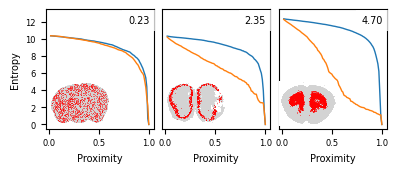

['331 Peri NN', '044 OB Dopa-Gaba', '030 L6 CT CTX Glut']

In [ ]:
TMG.update_current_type(0, "subclass")
section_to_idx = {sec: idx for idx, sec in enumerate(TMG.unqS)}
section_indices = np.array([section_to_idx[s] for s in TMG.Layers[0].Section])
type_by_section = pd.crosstab(section_indices, TMG.Layers[0].Type).values

tax_id = TAX_LEVELS.index("subclass")
n_sections = len(GPmat)
n_types = TMG.get_tax("subclass").N
integration_matrix = np.zeros((n_sections, n_types))

for sec_id in range(n_sections):
    diff_matrix = GPmat[sec_id, tax_id].ent_type_perm - GPmat[sec_id, tax_id].ent_type_real
    section_types = GPmat[sec_id, tax_id].unq_types
    for type_idx, type_val in enumerate(section_types):
        curve = np.abs(diff_matrix[:, type_idx])
        pbond_x = GPmat[sec_id, tax_id].pbond_vec[: len(curve)]
        integration_matrix[sec_id, int(type_val)] = np.trapz(curve, x=pbond_x)

example_indices = [(33, 27), (56, 253), (47, 209)]
subclass_tax = TMG.get_tax("subclass")

fig = plt.figure(figsize=(4.4, 1.55))
gs = plt.GridSpec(1, 3, figure=fig, wspace=0.08)

for panel_idx, (section_idx, type_idx) in enumerate(example_indices):
    ax = fig.add_subplot(gs[panel_idx])
    gp = GPmat[section_idx, tax_id]
    type_mask = gp.unq_types == type_idx

    ax.plot(gp.pbond_vec[1:], gp.ent_type_perm[:, type_mask], linewidth=1.0, color="#1f77b4")
    ax.plot(gp.pbond_vec[1:], gp.ent_type_real[:, type_mask], linewidth=1.0, color="#ff7f0e")
    ax.set_ylim([-0.5, 13.5])
    ax.set_xlabel("Proximity", fontsize=7)
    if panel_idx == 0:
        ax.set_ylabel(f"Map Information", fontsize=7)
    else:
        ax.set_yticks([])
    ax.tick_params(axis="both", labelsize=6)

    inset = ax.inset_axes([0.02, 0.02, 0.58, 0.38] if panel_idx < 2 else [-0.02, 0.02, 0.58, 0.38])
    xy_data = gp.XY
    type_data = gp.type_vec
    inset.plot(xy_data[type_data != type_idx, 0], -xy_data[type_data != type_idx, 1], ",", color="lightgray", alpha=0.5)
    inset.plot(xy_data[type_data == type_idx, 0], -xy_data[type_data == type_idx, 1], ",", color="red", alpha=0.5)
    inset.set_aspect("equal", adjustable="box")
    inset.set_xticks([])
    inset.set_yticks([])
    for spine in inset.spines.values():
        spine.set_visible(False)

    score = integration_matrix[section_idx, type_idx]
    ax.text(
        0.96,
        0.95,
        f"{score:.2f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=7,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75},
    )

plt.tight_layout()
fig.savefig(PANEL_PATHS["a"], dpi=300, bbox_inches="tight")
plt.show()

[subclass_tax.Type[type_idx] for _, type_idx in example_indices]


## Panels b and c: canonical taxonomy levels versus merged taxonomies

Panel `b` compares mean map information across the four canonical BICCN levels with the top-down and bottom-up merged solutions.

Panel `c` shows the hierarchical composition of the bottom-up and top-down solutions using the official BICCN color scheme.


*** OPTIMIZED TOP-DOWN ALGORITHM ***
Computing type contributions...
  Computing contribution 0/6893
  Computing contribution 1000/6893
  Computing contribution 2000/6893
  Computing contribution 3000/6893
  Computing contribution 4000/6893
  Computing contribution 5000/6893
  Computing contribution 6000/6893
Initial curr_ix size: 34, initial score: 3.406126

--- Iteration 1 ---
    Improvement #1: replaced 1 with 26 types, score: 3.409249, curr_ix size: 59
Iteration 1 complete:
  Time: 0.00s
  Improvements: 1
  Current score: 3.409249
  Current curr_ix size: 59

--- Iteration 2 ---
    Improvement #1: replaced 1 with 5 types, score: 3.419872, curr_ix size: 63
Iteration 2 complete:
  Time: 0.00s
  Improvements: 1
  Current score: 3.419872
  Current curr_ix size: 63

--- Iteration 3 ---
    Improvement #1: replaced 1 with 10 types, score: 3.625742, curr_ix size: 72
Iteration 3 complete:
  Time: 0.00s
  Improvements: 1
  Current score: 3.625742
  Current curr_ix size: 72

--- Iteration 4

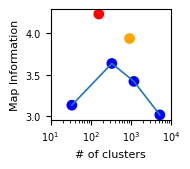

In [5]:
type_int_mat = np.zeros((TMG.N[0], len(TAX_LEVELS)))
for tax_idx, taxonomy in enumerate(TMG.Taxonomies):
    if taxonomy.name in TAX_LEVELS:
        type_int_mat[:, tax_idx] = taxonomy.get_type_ix(TMG.Layers[0].adata.obs[taxonomy.name])

GPmat_for_merge = GPmat.copy()
for col in range(GPmat_for_merge.shape[1]):
    for row in range(GPmat_for_merge.shape[0]):
        GPmat_for_merge[row, col].pbond_vec = GPmat_for_merge[row, col].pbond_vec[1:]

type_ix_td, best_score_td, type_vec_td = tmgu.merge_nested_clusters(GPmat_for_merge, top_down=True)
type_ix_bu, best_score_bu, type_vec_bu = tmgu.merge_nested_clusters(GPmat_for_merge, top_down=False)

tx_names = [taxonomy.name for taxonomy in TMG.Taxonomies[:4]]
tx_num = [taxonomy.N for taxonomy in TMG.Taxonomies[:4]]
tx_scr = list(GPscore.mean(axis=0))
tx_colors = ["blue"] * len(tx_num)

tx_names.extend(["top-down", "bottom-up"])
tx_num.extend([len(type_ix_td), len(type_ix_bu)])
tx_scr.extend([best_score_td, best_score_bu])
tx_colors.extend(["red", "orange"])

fig, ax = plt.subplots(figsize=(2.0, 1.8))
ax.plot(tx_num[:4], tx_scr[:4], "-", color="#1f77b4", linewidth=1.2)
ax.scatter(tx_num, tx_scr, c=tx_colors, s=45)
ax.set_xscale("log")
ax.set_xlim([10, 10000])
ax.set_xlabel("# of clusters", fontsize=8)
ax.set_ylabel("Map Information", fontsize=8)
ax.tick_params(axis="both", labelsize=7)
plt.tight_layout()
fig.savefig(PANEL_PATHS["b"], dpi=300, bbox_inches="tight")
plt.show()


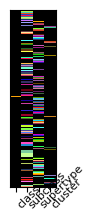

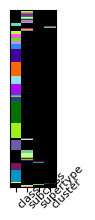

In [6]:
taxonomy_view_dir = locate_taxonomy_view_dir()
color_df = pd.read_csv(taxonomy_view_dir / "cluster_to_cluster_annotation_membership_color.csv")
color_df = color_df.set_index("cluster_alias").drop(columns=["neurotransmitter_color"])

mapping_df = pd.read_csv(taxonomy_view_dir / "cluster_to_cluster_annotation_membership_pivoted.csv")
mapping_df = mapping_df.set_index("cluster_alias").drop(columns=["neurotransmitter"])

merged_df = mapping_df.merge(color_df, left_index=True, right_index=True)
merged_df = merged_df.sort_values(["class", "subclass", "supertype", "cluster"])

mapping_df = merged_df[["class", "subclass", "supertype", "cluster"]]
color_df = merged_df[["class_color", "subclass_color", "supertype_color", "cluster_color"]]

ntypes_per_level = (type_int_mat.max(axis=0) + 1).astype(int)
cumsum_types = np.concatenate([[0], np.cumsum(ntypes_per_level)])


def extract_level_names(type_indices):
    level_names = [[] for _ in range(4)]
    for type_idx in np.asarray(type_indices):
        level = np.searchsorted(cumsum_types[1:], type_idx, side="right")
        original_code = type_idx - cumsum_types[level]
        level_names[level].append(TMG.Taxonomies[level].Type[original_code])
    return level_names


level_names_bu = extract_level_names(type_ix_bu)
level_names_td = extract_level_names(type_ix_td)

bu_df = merged_df.copy()
td_df = merged_df.copy()
black_hex = "#000000"

for level_idx, level_name in enumerate(TAX_LEVELS):
    name_col = level_name
    color_col = f"{level_name}_color"
    bu_df.loc[~bu_df[name_col].isin(level_names_bu[level_idx]), color_col] = black_hex
    td_df.loc[~td_df[name_col].isin(level_names_td[level_idx]), color_col] = black_hex

fig_left, _ = plot_color_matrix_heatmap(
    bu_df.drop(columns=TAX_LEVELS),
    figsize=(1.0, 2.3),
)
fig_left.savefig(PANEL_PATHS["c_left"], dpi=300, bbox_inches="tight")
plt.show()

fig_right, _ = plot_color_matrix_heatmap(
    td_df.drop(columns=TAX_LEVELS),
    figsize=(1.0, 2.3),
)
fig_right.savefig(PANEL_PATHS["c_right"], dpi=300, bbox_inches="tight")
plt.show()


## Panels d, e, and f: clustering diversity and optimization results

These panels summarize the clustering sweep, the relationship between type entropy and map information, and the ranking of clustering strategies by their best score.


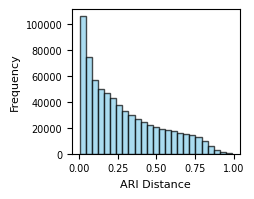

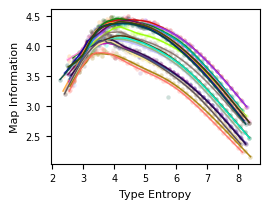

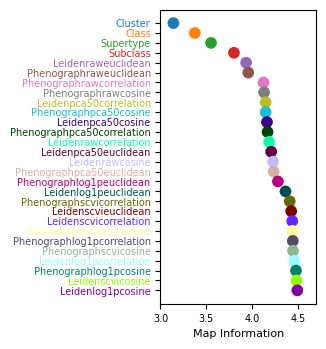

,algorithm,raw_score_weighted_mean,total_number_of_types,type_distribution_entropy
554,Cluster,3.140985,5320.0,5.748369
823,Class,3.374412,34.0,2.671634
687,Supertype,3.551069,1201.0,4.828185
592,Subclass,3.800814,338.0,4.034461
750,Leidenraweuclidean,3.933167,79.0,3.677565
606,Phenographraweuclidean,3.956694,75.0,3.577357
981,Phenographrawcorrelation,4.122609,181.0,4.244830
980,Phenographrawcosine,4.128941,156.0,4.079565
976,Leidenpca50correlation,4.145720,61.0,3.674805
551,Phenographpca50cosine,4.145839,66.0,3.772311


In [ ]:
reduced_scores = pd.read_csv(DATA_DIR / "OptResults" / "cell_type_percolation_scores_reduced.csv")
ari_df = pd.read_csv(DATA_DIR / "OptResults" / "ari_cell_clusters.csv", index_col=0)

condensed_ari = ari_df["ari"].dropna().to_numpy()

fig, ax = plt.subplots(figsize=(2.6, 2.1))
ax.hist(condensed_ari, bins=25, color="skyblue", edgecolor="black", alpha=0.7)
ax.set_xlabel("ARI Distance", fontsize=8)
ax.set_ylabel("Frequency", fontsize=8)
ax.tick_params(axis="both", labelsize=7)
plt.tight_layout()
fig.savefig(PANEL_PATHS["d"], dpi=300, bbox_inches="tight")
plt.show()

algos = reduced_scores["algorithm"].unique()
colors = cc.glasbey_bw[: len(algos)]
lowess_frac = 0.2
spline_smooths = {}

for algo in algos:
    subset = reduced_scores[reduced_scores["algorithm"] == algo].copy()
    x = subset["type_distribution_entropy"].to_numpy(dtype=float)
    y = subset["raw_score_weighted_mean"].to_numpy(dtype=float)
    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]
    if len(x) >= 5:
        smoothed = lowess(y, x, frac=lowess_frac, return_sorted=True)
        spline_smooths[algo] = (smoothed[:, 0], smoothed[:, 1])
    else:
        spline_smooths[algo] = (x, y)

fig, ax = plt.subplots(figsize=(2.8, 2.2))
for color, algo in zip(colors, algos):
    subset = reduced_scores[reduced_scores["algorithm"] == algo]
    ax.scatter(
        subset["type_distribution_entropy"],
        subset["raw_score_weighted_mean"],
        color=color,
        alpha=0.25,
        s=10,
        linewidth=0,
    )
    x_smooth, y_smooth = spline_smooths[algo]
    ax.plot(x_smooth, y_smooth, color=color, linewidth=1.1, alpha=0.9)
ax.set_xlabel("Cell Type Entropy", fontsize=8)
ax.set_ylabel("Map Information", fontsize=8)
ax.tick_params(axis="both", labelsize=7)
plt.tight_layout()
fig.savefig(PANEL_PATHS["e"], dpi=300, bbox_inches="tight")
plt.show()

idx = reduced_scores.groupby("algorithm")["raw_score_weighted_mean"].idxmax()
df_max = reduced_scores.loc[
    idx,
    ["algorithm", "raw_score_weighted_mean", "total_number_of_types", "type_distribution_entropy"],
].sort_values("raw_score_weighted_mean")
df_max["algorithm"] = df_max["algorithm"].str.replace(r"^Preexisting_", "", regex=True).str.capitalize()

rank_colors = cc.glasbey_category10[: df_max.shape[0]]
fig, ax = plt.subplots(figsize=(3.0, 3.5))
y_positions = -np.arange(df_max.shape[0])
ax.scatter(df_max["raw_score_weighted_mean"], y_positions, c=rank_colors, s=55)
ax.set_xlim((3.0, 4.7))
ax.set_xticks((3.0, 3.5, 4.0, 4.5))
ax.set_xlabel("Map Information", fontsize=8)
ax.set_yticks(y_positions)
ax.set_yticklabels(df_max["algorithm"], fontsize=7)
for ticklabel, color in zip(ax.get_yticklabels(), rank_colors):
    ticklabel.set_color(color)
ax.tick_params(axis="x", labelsize=7)
plt.subplots_adjust(left=0.45, bottom=0.14, right=0.97, top=0.98)
fig.savefig(PANEL_PATHS["f"], dpi=300, bbox_inches="tight")
plt.show()

df_max


## Panel g: spatial comparison of the subclass taxonomy and the optimized taxonomy

This panel uses cell geometries from the TMG object and displays a matched section under the `subclass` and `opt_cell` taxonomies.


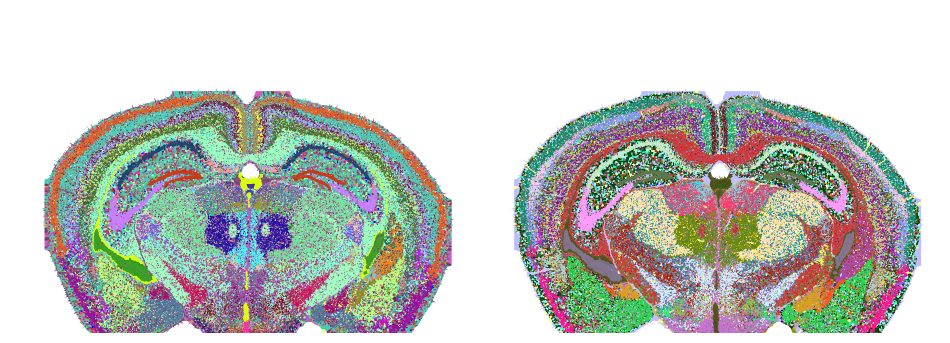

In [8]:
TMG.load_geoms()

example_section = next(section for section in TMG.unqS if str(section).endswith(".36"))
original_taxonomy = TMG.layer_taxonomy_mapping[0]


def add_cell_typemap(view, section, tax_name, pos, title):
    TMG.update_current_type(0, tax_name)
    panel = Viz.TypeMap(
        geom_type=TMG.layer_to_geom_type_mapping["cell"],
        V=view,
        section=section,
        pos=pos,
        name=title,
        rotation=180,
    )
    view.Panels.append(panel)
    return panel


single_section_view = Viz.View(TMG, name=f"{example_section} taxonomy comparison", figsize=(12, 6))
gs = single_section_view.fig.add_gridspec(1, 2, wspace=0.02, hspace=0.0)
panels = [
    add_cell_typemap(single_section_view, example_section, "subclass", gs[0, 0], "subclass"),
    add_cell_typemap(single_section_view, example_section, "opt_cell", gs[0, 1], "opt_cell"),
]

single_section_view.show()
for panel in panels:
    panel.ax.set_title("")
plt.show()

TMG.update_current_type(0, original_taxonomy)
single_section_view.fig.savefig(PANEL_PATHS["g"], dpi=300, bbox_inches="tight")


## Assemble the full figure mock

This final step arranges the saved panel PNGs into a single composite image that follows the organization of the reference figure. The output is a figure-layout mock rather than a publication-polished final plate.


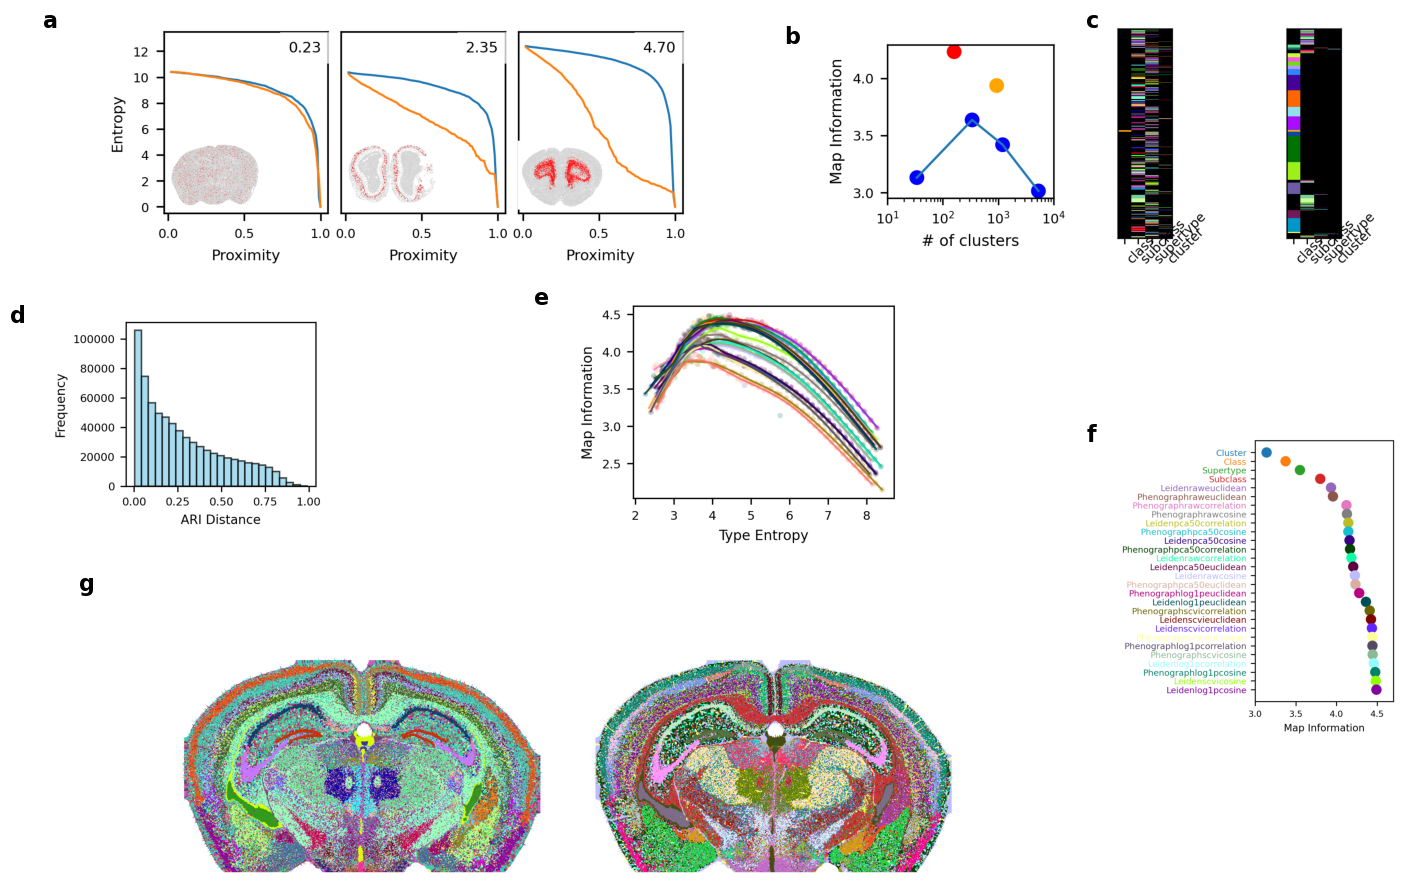

PosixPath('/home/rwollman/MyProjects/MaxInfoCart/Figures/Figure2_mock.png')

In [9]:
missing_panels = [key for key, path in PANEL_PATHS.items() if key != "mock" and not path.exists()]
if missing_panels:
    raise FileNotFoundError(f"Missing panel images: {missing_panels}")

fig = plt.figure(figsize=(14, 8.8), constrained_layout=True)
outer = fig.add_gridspec(
    nrows=3,
    ncols=4,
    height_ratios=[1.0, 1.0, 1.15],
    width_ratios=[1.1, 1.35, 1.0, 1.1],
)

ax_a = fig.add_subplot(outer[0, 0:2])
show_image(ax_a, PANEL_PATHS["a"])
add_panel_label(ax_a, "a")

ax_b = fig.add_subplot(outer[0, 2])
show_image(ax_b, PANEL_PATHS["b"])
add_panel_label(ax_b, "b")

c_grid = outer[0, 3].subgridspec(1, 2, wspace=0.04)
ax_c1 = fig.add_subplot(c_grid[0, 0])
ax_c2 = fig.add_subplot(c_grid[0, 1])
show_image(ax_c1, PANEL_PATHS["c_left"])
show_image(ax_c2, PANEL_PATHS["c_right"])
add_panel_label(ax_c1, "c")

ax_d = fig.add_subplot(outer[1, 0])
show_image(ax_d, PANEL_PATHS["d"])
add_panel_label(ax_d, "d")

ax_e = fig.add_subplot(outer[1, 1:3])
show_image(ax_e, PANEL_PATHS["e"])
add_panel_label(ax_e, "e")

ax_f = fig.add_subplot(outer[1:, 3])
show_image(ax_f, PANEL_PATHS["f"])
add_panel_label(ax_f, "f")

ax_g = fig.add_subplot(outer[2, 0:3])
show_image(ax_g, PANEL_PATHS["g"])
add_panel_label(ax_g, "g")

fig.savefig(PANEL_PATHS["mock"], dpi=300, bbox_inches="tight")
plt.show()

PANEL_PATHS["mock"]
